# Credit Risk Modeling: Static vs Sequential Approaches

Logistic Regression, XGBoost, and LSTM — binary default prediction on mobile money data.

## 1. Setup

In [2]:
import sys
import os

# Ensure seqcredit_model package is importable from notebooks directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(project_root, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from seqcredit_model.credit_model import (
    CreditRiskDataLoader, LogisticRegressionModel,
    XGBoostModel, LSTMModel, ModelEvaluator, set_random_seeds
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

set_random_seeds(42)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


## 2. Data Exploration

In [ ]:
# Load raw data for exploration
df_features = pd.read_csv(os.path.join(project_root, 'data/user_features.csv'))
df_summaries = pd.read_csv(os.path.join(project_root, 'data/user_labels.csv'))

print(f'User features: {df_features.shape}')
print(f'User summaries: {df_summaries.shape}')
print(f'\nCredit risk label distribution (all users):')
print(df_summaries['credit_risk_label'].value_counts().sort_index())

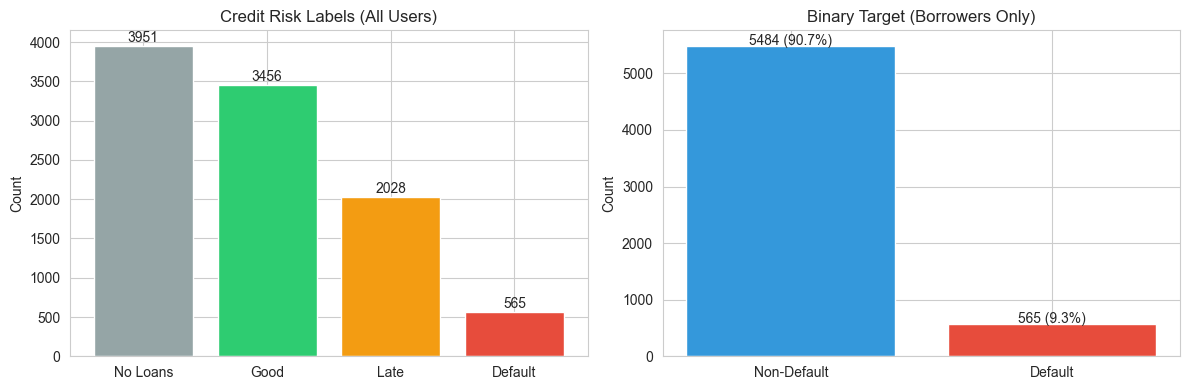


Total borrowers: 6049
Default rate: 0.093 (565 defaults)


In [4]:
# Visualize target distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# All users
labels_all = df_summaries['credit_risk_label'].value_counts().sort_index()
label_names = {-1: 'No Loans', 0: 'Good', 1: 'Late', 2: 'Default'}
ax1.bar([label_names[k] for k in labels_all.index], labels_all.values,
        color=['#95a5a6', '#2ecc71', '#f39c12', '#e74c3c'])
ax1.set_title('Credit Risk Labels (All Users)')
ax1.set_ylabel('Count')
for i, v in enumerate(labels_all.values):
    ax1.text(i, v + 50, str(v), ha='center')

# Borrowers only (binary target)
borrowers = df_summaries[df_summaries['credit_risk_label'] != -1]
binary = (borrowers['credit_risk_label'] == 2).astype(int)
counts = binary.value_counts().sort_index()
ax2.bar(['Non-Default', 'Default'], counts.values,
        color=['#3498db', '#e74c3c'])
ax2.set_title('Binary Target (Borrowers Only)')
ax2.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax2.text(i, v + 20, f'{v} ({v/len(borrowers)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.show()

print(f'\nTotal borrowers: {len(borrowers)}')
print(f'Default rate: {binary.mean():.3f} ({binary.sum()} defaults)')

In [5]:
# Credit archetype distribution among borrowers
print('Credit archetypes (borrowers):')
print(borrowers['credit_archetype'].value_counts())

Credit archetypes (borrowers):
credit_archetype
responsible_borrower    3511
occasional_borrower     1504
risky_borrower           824
defaulter                210
Name: count, dtype: int64


## 3. Data Preparation

In [ ]:
# Initialize data loader with paths relative to project root
loader = CreditRiskDataLoader(
    features_path=os.path.join(project_root, 'data/user_features.csv'),
    summaries_path=os.path.join(project_root, 'data/user_labels.csv'),
    transactions_dir=os.path.join(project_root, 'data/user_transactions'),
)

# Prepare static data splits
static_data = loader.prepare_static_splits()

print(f"Training samples: {len(static_data['y_train'])}")
print(f"Test samples: {len(static_data['y_test'])}")
print(f"Default rate (train): {static_data['y_train'].mean():.4f}")
print(f"Default rate (test): {static_data['y_test'].mean():.4f}")
print(f"Features: {len(static_data['feature_names'])}")
print(f"Scale pos weight: {loader.get_scale_pos_weight():.2f}")
print(f"\nFeature list:")
for i, name in enumerate(static_data['feature_names']):
    print(f"  {i+1:2d}. {name}")

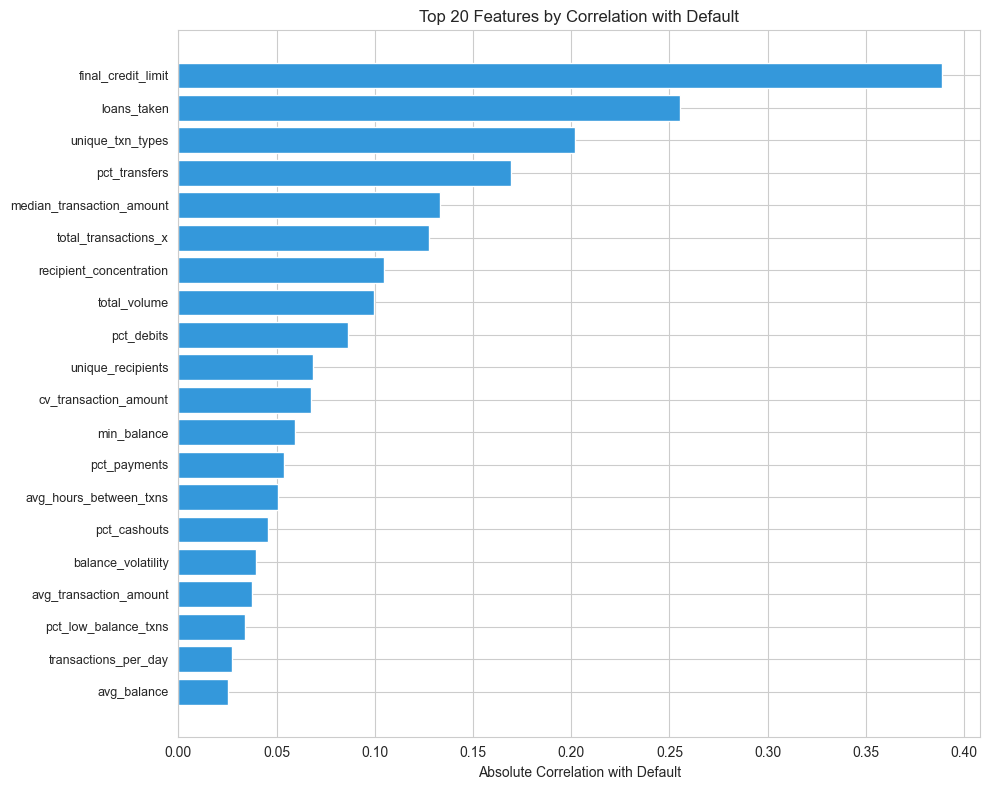

In [7]:
# Feature correlation with target (top features)
X_train_df = static_data['X_train'].copy()
X_train_df['default'] = static_data['y_train']
correlations = X_train_df.corr()['default'].drop('default').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_corr = correlations.head(20)
ax.barh(range(len(top_corr)), top_corr.values, color='#3498db')
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index, fontsize=9)
ax.set_xlabel('Absolute Correlation with Default')
ax.set_title('Top 20 Features by Correlation with Default')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Logistic Regression

In [8]:
# Train Logistic Regression
lr_model = LogisticRegressionModel(class_weight='balanced')
lr_model.fit(static_data['X_train_scaled'], static_data['y_train'])

# Cross-validation
print('Logistic Regression - 5-Fold Cross-Validation:')
lr_cv = lr_model.cross_validate(static_data['X_train_scaled'], static_data['y_train'])
for metric, values in lr_cv.items():
    print(f'  {metric}: {np.mean(values):.4f} +/- {np.std(values):.4f}')

Logistic Regression - 5-Fold Cross-Validation:
  auc_roc: 0.9784 +/- 0.0046
  auc_pr: 0.8644 +/- 0.0242
  f1: 0.6491 +/- 0.0236
  accuracy: 0.9054 +/- 0.0081


In [9]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Test predictions
lr_proba = lr_model.predict_proba(static_data['X_test_scaled'])

print('Logistic Regression - Test Set Performance:')
print(f'  AUC-ROC: {roc_auc_score(static_data["y_test"], lr_proba):.4f}')
print(f'  AUC-PR: {average_precision_score(static_data["y_test"], lr_proba):.4f}')

Logistic Regression - Test Set Performance:
  AUC-ROC: 0.9717
  AUC-PR: 0.8134


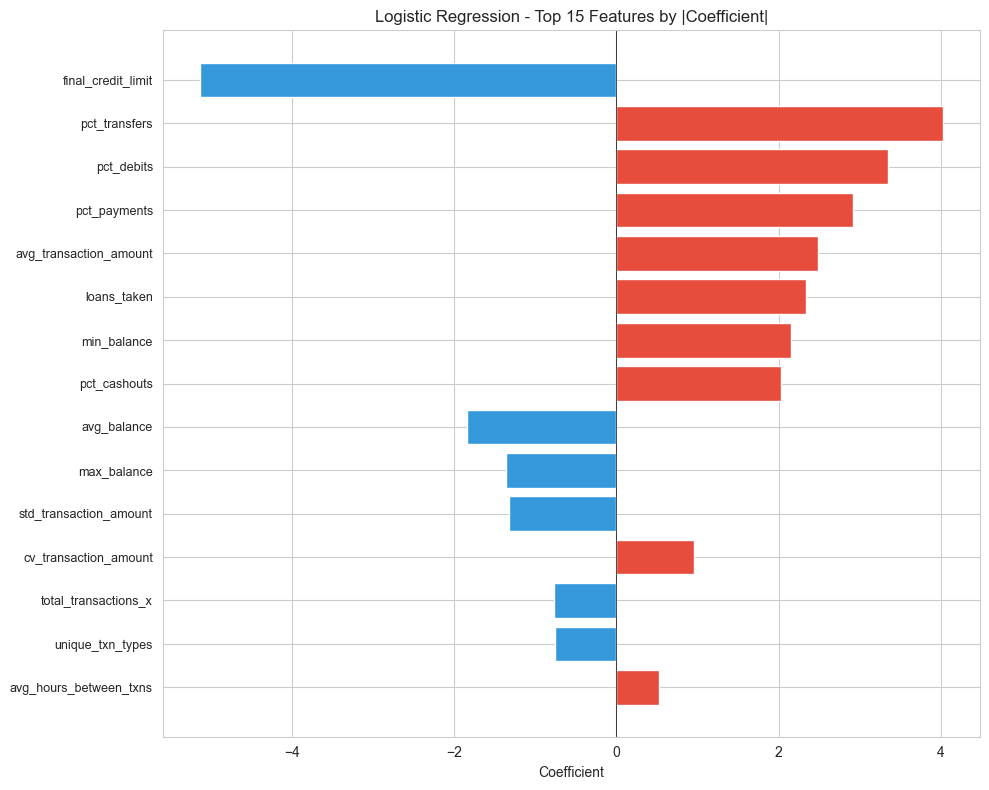

Red = increases default probability, Blue = decreases


In [10]:
# Feature coefficients
lr_coefs = lr_model.get_coefficients(static_data['feature_names'])

fig, ax = plt.subplots(figsize=(10, 8))
top_coefs = lr_coefs.head(15)
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top_coefs['coefficient']]
ax.barh(range(len(top_coefs)), top_coefs['coefficient'], color=colors)
ax.set_yticks(range(len(top_coefs)))
ax.set_yticklabels(top_coefs['feature'], fontsize=9)
ax.set_xlabel('Coefficient')
ax.set_title('Logistic Regression - Top 15 Features by |Coefficient|')
ax.invert_yaxis()
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Red = increases default probability, Blue = decreases')

## 5. XGBoost Classifier

In [11]:
# Train XGBoost — carve a validation split from training data (no test leakage)
from sklearn.model_selection import train_test_split as tts
X_tr, X_val_xgb, y_tr, y_val_xgb = tts(
    static_data['X_train_scaled'], static_data['y_train'],
    test_size=0.15, stratify=static_data['y_train'], random_state=42
)
xgb_model = XGBoostModel(scale_pos_weight=loader.get_scale_pos_weight())
xgb_model.fit(X_tr, y_tr, X_val=X_val_xgb, y_val=y_val_xgb)

# Cross-validation
print('XGBoost - 5-Fold Cross-Validation:')
xgb_cv = xgb_model.cross_validate(static_data['X_train_scaled'], static_data['y_train'])
for metric, values in xgb_cv.items():
    print(f'  {metric}: {np.mean(values):.4f} +/- {np.std(values):.4f}')

XGBoost - 5-Fold Cross-Validation:
  auc_roc: 0.9595 +/- 0.0086
  auc_pr: 0.7565 +/- 0.0333
  f1: 0.6559 +/- 0.0310
  accuracy: 0.9279 +/- 0.0067


In [12]:
# Test predictions
xgb_proba = xgb_model.predict_proba(static_data['X_test_scaled'])

print('XGBoost - Test Set Performance:')
print(f'  AUC-ROC: {roc_auc_score(static_data["y_test"], xgb_proba):.4f}')
print(f'  AUC-PR: {average_precision_score(static_data["y_test"], xgb_proba):.4f}')

XGBoost - Test Set Performance:
  AUC-ROC: 0.9586
  AUC-PR: 0.7461


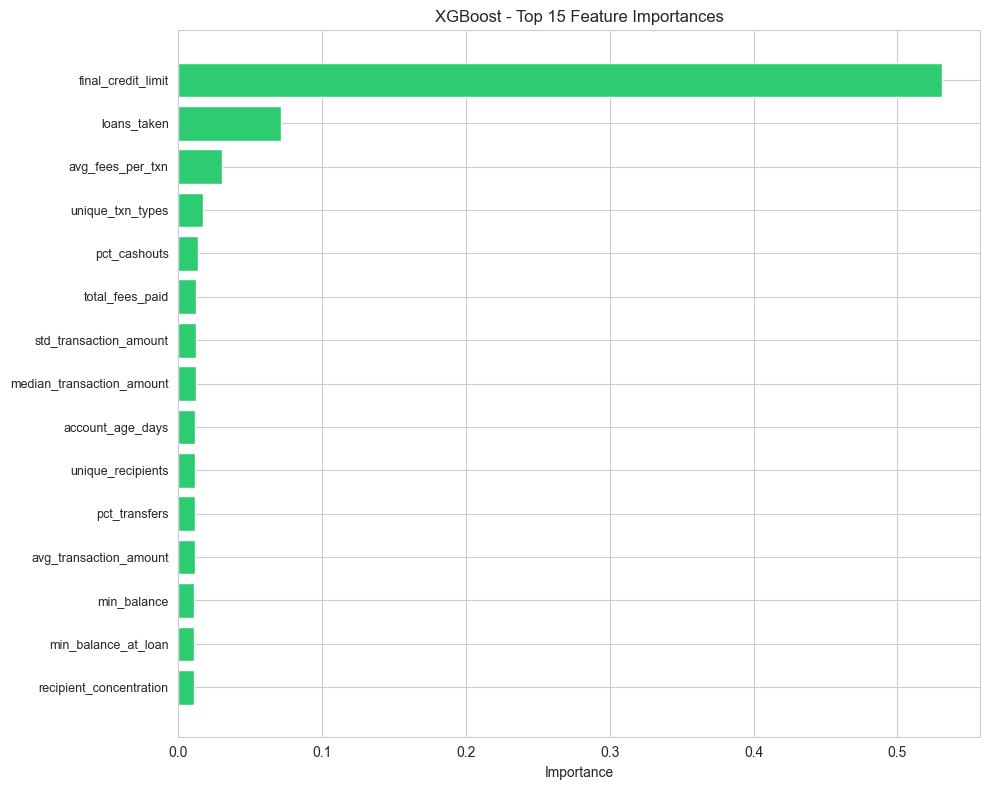

In [13]:
# Feature importance
xgb_importance = xgb_model.get_feature_importance(static_data['feature_names'])

fig, ax = plt.subplots(figsize=(10, 8))
top_imp = xgb_importance.head(15)
ax.barh(range(len(top_imp)), top_imp['importance'], color='#2ecc71')
ax.set_yticks(range(len(top_imp)))
ax.set_yticklabels(top_imp['feature'], fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('XGBoost - Top 15 Feature Importances')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. LSTM Model

In [14]:
# Load sequence data
seq_data = loader.load_sequences(
    max_seq_len=100,
    cache_path=os.path.join(project_root, 'data/lstm_sequences.npz'),
)

print(f"Train sequences shape: {seq_data['X_train_seq'].shape}")
print(f"Test sequences shape: {seq_data['X_test_seq'].shape}")
print(f"Train default rate: {seq_data['y_train'].mean():.4f}")
print(f"Test default rate: {seq_data['y_test'].mean():.4f}")
print(f"LSTM features ({len(seq_data['feature_names'])}):")
for i, name in enumerate(seq_data['feature_names']):
    print(f"  {i+1:2d}. {name}")

Processing 6049 borrower transaction files...
  Processed 1000/6049 users...
  Processed 2000/6049 users...
  Processed 3000/6049 users...
  Processed 4000/6049 users...
  Processed 5000/6049 users...
  Processed 6000/6049 users...
  Processed 6049/6049 users...
  Train sequences: 4839, Test sequences: 1210
Cached sequences to c:\Users\Dell\Projects\seqcredit-model\data/lstm_sequences.npz
Shapes: train=(4839, 100, 38), test=(1210, 100, 38)
Train sequences shape: (4839, 100, 38)
Test sequences shape: (1210, 100, 38)
Train default rate: 0.0934
Test default rate: 0.0934
LSTM features (38):
   1. log_amount
   2. is_micro_txn
   3. is_small_txn
   4. is_medium_txn
   5. is_large_txn
   6. fee_to_amount_ratio
   7. total_cost
   8. has_fees
   9. is_transfer
  10. is_debit
  11. is_payment
  12. is_payment_send
  13. is_cash_out
  14. is_cash_in
  15. is_adjustment
  16. hour_sin
  17. hour_cos
  18. day_sin
  19. day_cos
  20. is_weekend
  21. time_since_last_txn_hours
  22. log_balance_be

In [15]:
# Build and train LSTM
input_shape = (seq_data['X_train_seq'].shape[1], seq_data['X_train_seq'].shape[2])

# Balanced class weights computed from training labels only
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(seq_data['y_train'])
weights = compute_class_weight('balanced', classes=classes, y=seq_data['y_train'])
class_weights = dict(zip(classes.astype(int), weights))
print(f'Class weights: {class_weights}')

lstm_model = LSTMModel(
    lstm_units_1=32,
    lstm_units_2=16,
    dense_units=8,
    dropout_rate=0.4,
    learning_rate=0.0005,
)
lstm_model.build_model(input_shape)
lstm_model.model.summary()

# Use validation_split from training data — do not expose test set during training
history = lstm_model.fit(
    seq_data['X_train_seq'], seq_data['y_train'],
    epochs=100, batch_size=32,
    class_weight=class_weights,
)

Class weights: {np.int64(0): np.float64(0.5515158422612263), np.int64(1): np.float64(5.352876106194691)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 100, 38)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 32)        │         9,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,369 (48.32 KB)

 Trainable params: 12,369 (48.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 127s 711ms/step - auc: 0.4806 - loss: 0.6948 - val_auc: 0.4911 - val_loss: 0.6880 - learning_rate: 5.0000e-04
Epoch 2/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 95s 347ms/step - auc: 0.5156 - loss: 0.6883 - val_auc: 0.4736 - val_loss: 0.6768 - learning_rate: 5.0000e-04
Epoch 3/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 41s 314ms/step - auc: 0.5231 - loss: 0.6859 - val_auc: 0.4839 - val_loss: 0.6588 - learning_rate: 5.0000e-04
Epoch 4/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 82s 637ms/step - auc: 0.5315 - loss: 0.6845 - val_auc: 0.4781 - val_loss: 0.6656 - learning_rate: 5.0000e-04
Epoch 5/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - auc: 0.5314 - loss: 0.6868 - val_auc: 0.4849 - val_loss: 0.6817 - learning_rate: 5.0000e-04
Epoch 6/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 102s 787ms/step - auc: 0.5499 - loss: 0.6844 - val_auc: 0.4917 - val_loss: 0.6766 - learning_rate: 5.0000e-04
Epoch 7/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 145s 809ms/step - auc: 0.5419 - loss: 0.6847 - val_auc: 0.4

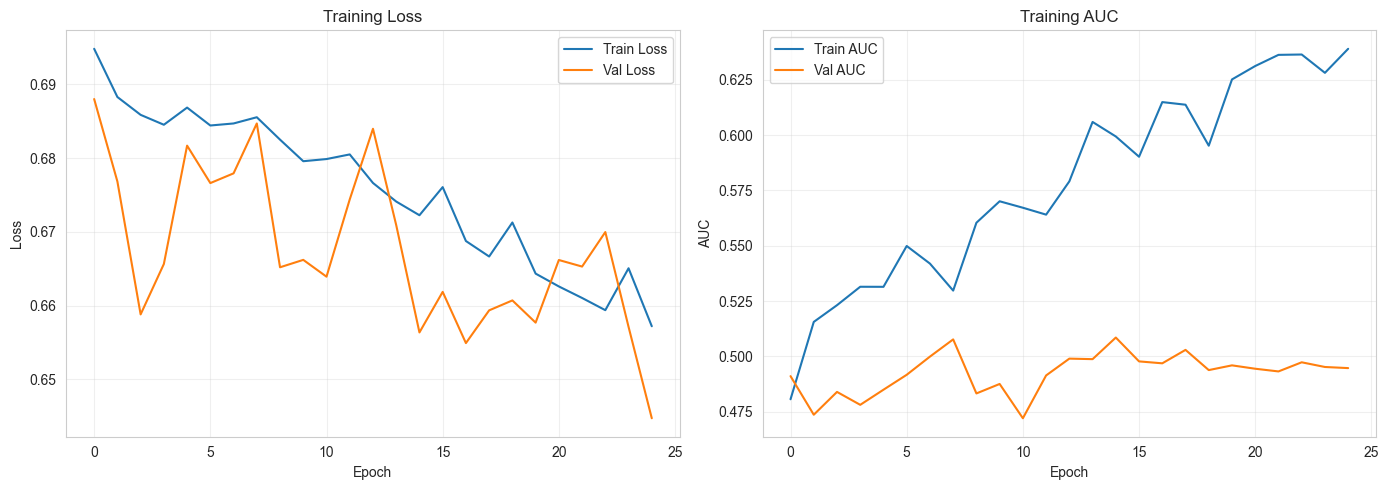

In [16]:
# Training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['auc'], label='Train AUC')
ax2.plot(history.history['val_auc'], label='Val AUC')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.set_title('Training AUC')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Test predictions
lstm_proba = lstm_model.predict_proba(seq_data['X_test_seq'])

print('LSTM - Test Set Performance:')
print(f'  AUC-ROC: {roc_auc_score(seq_data["y_test"], lstm_proba):.4f}')
print(f'  AUC-PR: {average_precision_score(seq_data["y_test"], lstm_proba):.4f}')

LSTM - Test Set Performance:
  AUC-ROC: 0.5048
  AUC-PR: 0.1070


In [18]:
# LSTM cross-validation removed — single train/test split with early stopping
# is sufficient for comparison purposes and avoids the high variance and
# significant compute cost of 5-fold CV on sequential data.
print('LSTM cross-validation skipped (see cell 26 for LR and XGBoost CV results).')

LSTM cross-validation skipped (see cell 26 for LR and XGBoost CV results).


## 7. Model Comparison

In [19]:
# Create evaluator with the shared test set
evaluator = ModelEvaluator(static_data['y_test'])
evaluator.add_model('Logistic Regression', lr_proba)
evaluator.add_model('XGBoost', xgb_proba)
evaluator.add_model('LSTM', lstm_proba)

# Comparison table
comparison = evaluator.get_comparison_table()
print('\nModel Comparison (Test Set):')
print(comparison.round(4).to_string())


Model Comparison (Test Set):
                     AUC-ROC  AUC-PR      F1  Precision  Recall  Accuracy
Model                                                                    
Logistic Regression   0.9717  0.8134  0.6503     0.4977  0.9381    0.9058
XGBoost               0.9586  0.7461  0.6299     0.5674  0.7080    0.9223
LSTM                  0.4770  0.0976  0.1156     0.0772  0.2301    0.6711


In [20]:
# Cross-validation comparison (LR and XGBoost only; LSTM uses single split)
cv_results = {}
for name, cv in [('Logistic Regression', lr_cv), ('XGBoost', xgb_cv)]:
    cv_results[name] = {
        metric: f"{np.mean(values):.4f} +/- {np.std(values):.4f}"
        for metric, values in cv.items()
    }

cv_df = pd.DataFrame(cv_results).T
print('\nCross-Validation Results (5-Fold, static models):')
print(cv_df.to_string())


Cross-Validation Results (5-Fold, static models):
                               auc_roc             auc_pr                 f1           accuracy
Logistic Regression  0.9784 +/- 0.0046  0.8644 +/- 0.0242  0.6491 +/- 0.0236  0.9054 +/- 0.0081
XGBoost              0.9595 +/- 0.0086  0.7565 +/- 0.0333  0.6559 +/- 0.0310  0.9279 +/- 0.0067


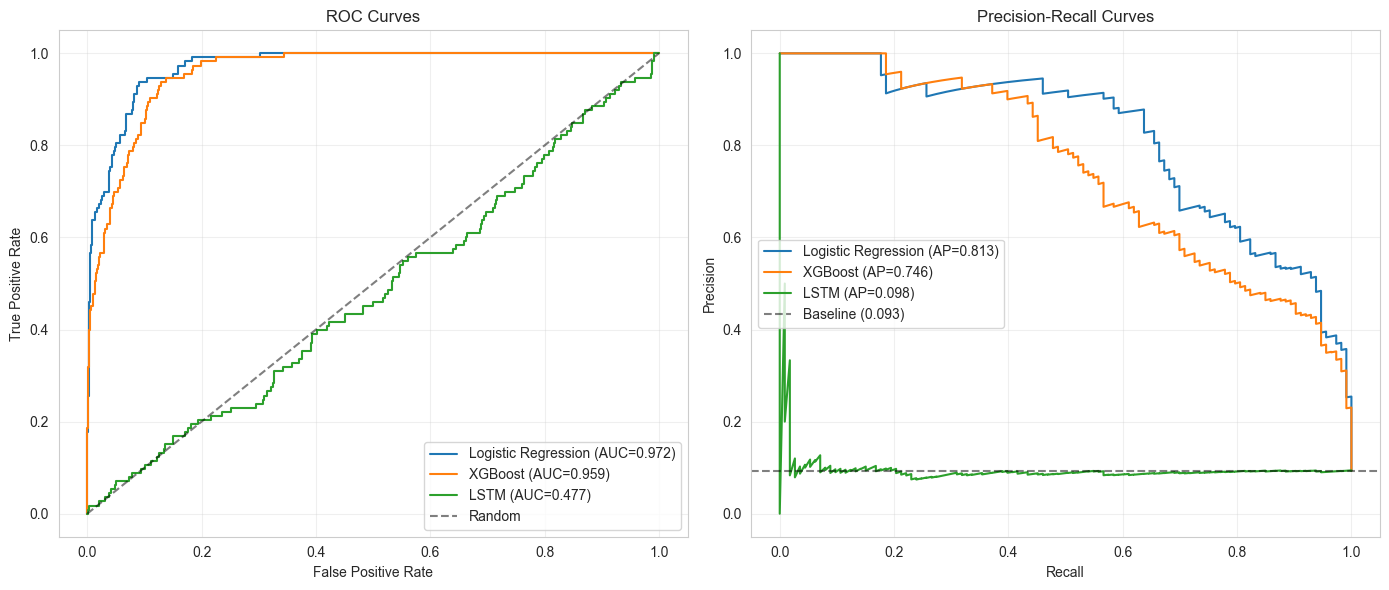

In [21]:
# ROC and PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
evaluator.plot_roc_curves(ax=ax1)
evaluator.plot_pr_curves(ax=ax2)
plt.tight_layout()
plt.show()

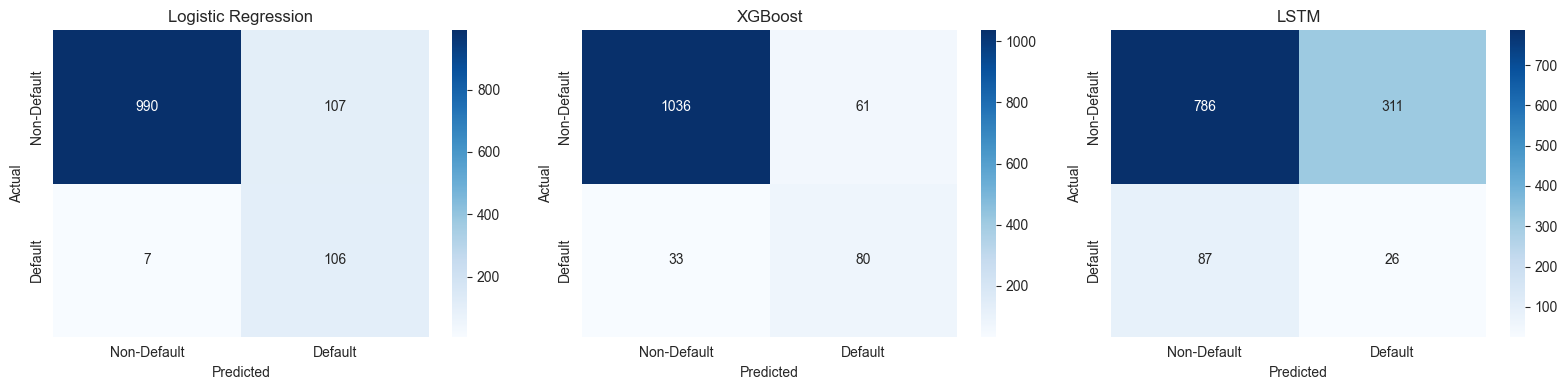

In [22]:
# Confusion matrices
evaluator.plot_confusion_matrices(figsize=(16, 4))
plt.show()

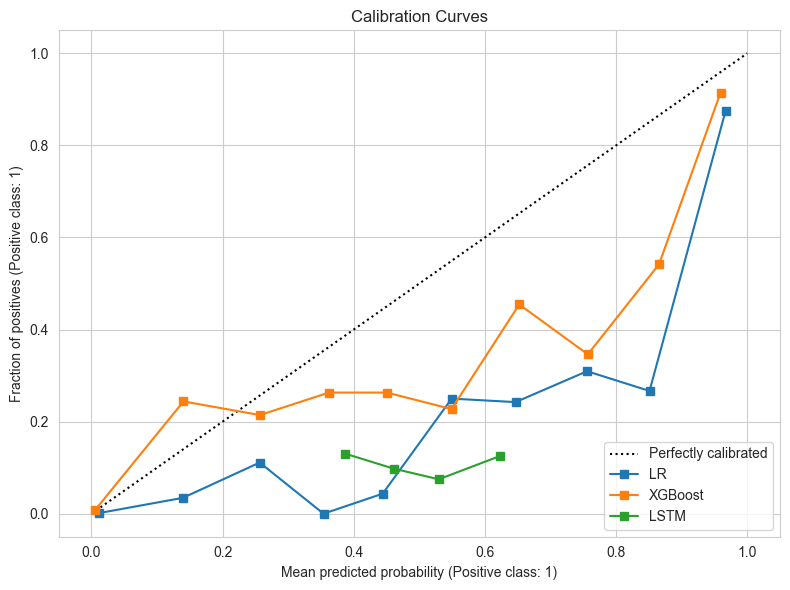

In [23]:
# Calibration curves
from sklearn.calibration import CalibrationDisplay
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba in [('LR', lr_proba), ('XGBoost', xgb_proba), ('LSTM', lstm_proba)]:
    CalibrationDisplay.from_predictions(
        static_data['y_test'], proba, n_bins=10, ax=ax, name=name
    )
ax.set_title('Calibration Curves')
plt.tight_layout()
plt.show()

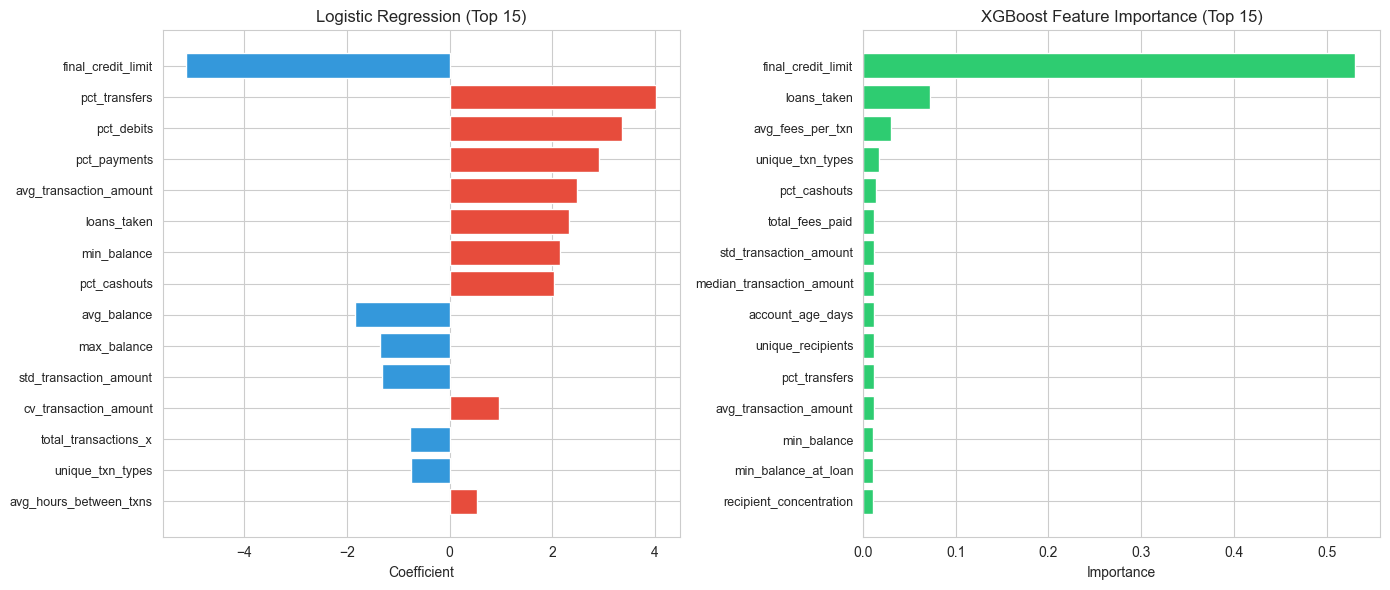

In [24]:
# Feature importance comparison (LR vs XGBoost)
evaluator.plot_feature_importance_comparison(
    lr_coefs, xgb_importance, top_n=15
)
plt.show()

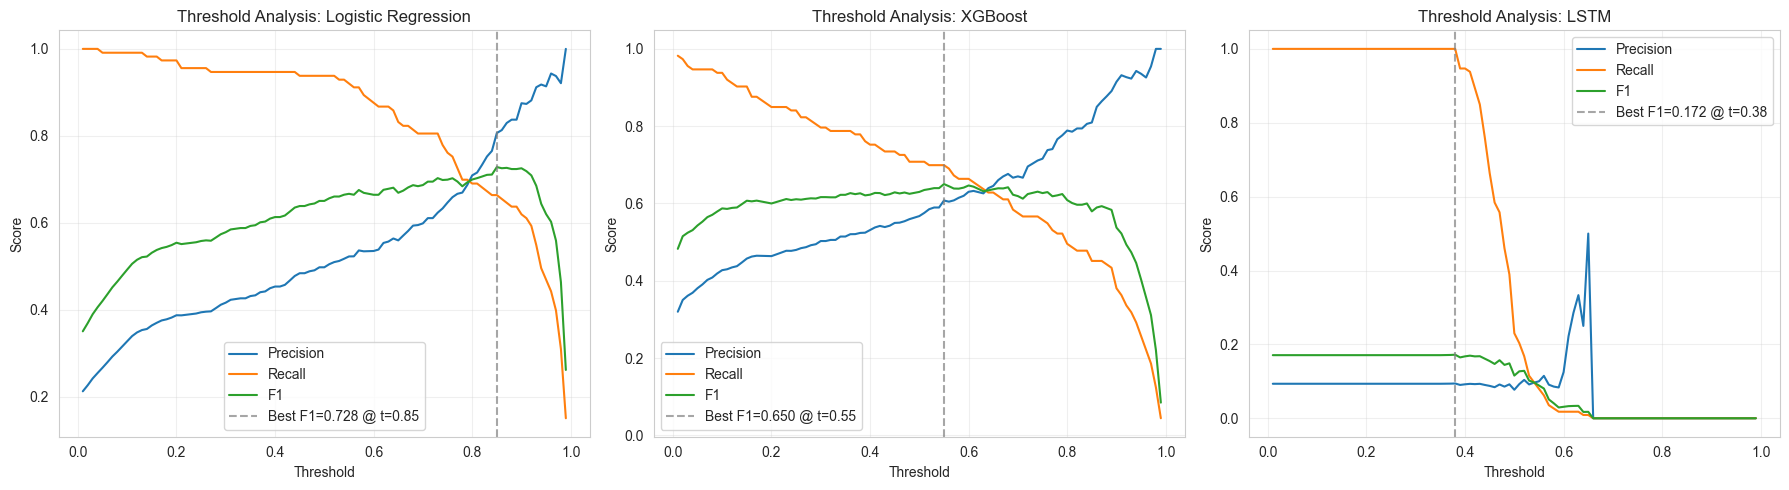

In [25]:
# Threshold analysis for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes, ['Logistic Regression', 'XGBoost', 'LSTM']):
    evaluator.plot_threshold_analysis(name, ax=ax)
plt.tight_layout()
plt.show()

In [26]:
# Classification reports
evaluator.print_classification_reports()


  Logistic Regression
              precision    recall  f1-score   support

 Non-Default       0.99      0.90      0.95      1097
     Default       0.50      0.94      0.65       113

    accuracy                           0.91      1210
   macro avg       0.75      0.92      0.80      1210
weighted avg       0.95      0.91      0.92      1210


  XGBoost
              precision    recall  f1-score   support

 Non-Default       0.97      0.94      0.96      1097
     Default       0.57      0.71      0.63       113

    accuracy                           0.92      1210
   macro avg       0.77      0.83      0.79      1210
weighted avg       0.93      0.92      0.93      1210


  LSTM
              precision    recall  f1-score   support

 Non-Default       0.90      0.72      0.80      1097
     Default       0.08      0.23      0.12       113

    accuracy                           0.67      1210
   macro avg       0.49      0.47      0.46      1210
weighted avg       0.82      0.6

## 8. Analysis

- AUC-PR is the primary metric given ~9% default rate (class imbalance).
- Balance-related features dominate LR and XGBoost importance.
- LSTM lift over static models indicates sequential patterns add signal.

In [27]:
# Save comparison table
comparison.to_csv(os.path.join(project_root, 'data/model_comparison.csv'))
print('Comparison table saved to data/model_comparison.csv')

Comparison table saved to data/model_comparison.csv
